In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load clean data
df = pd.read_csv(r'C:\Users\mydwm\OneDrive\Desktop\job_market_analysis\output\jobs_clean.csv')
df_main = pd.read_csv(r'C:\Users\mydwm\OneDrive\Desktop\job_market_analysis\output\jobs_main.csv')

print("✅ Data Loaded!")
print(f"Full dataset: {df.shape[0]:,} rows")
print(f"Main dataset: {df_main.shape[0]:,} rows")

✅ Data Loaded!
Full dataset: 207,531 rows
Main dataset: 123,849 rows


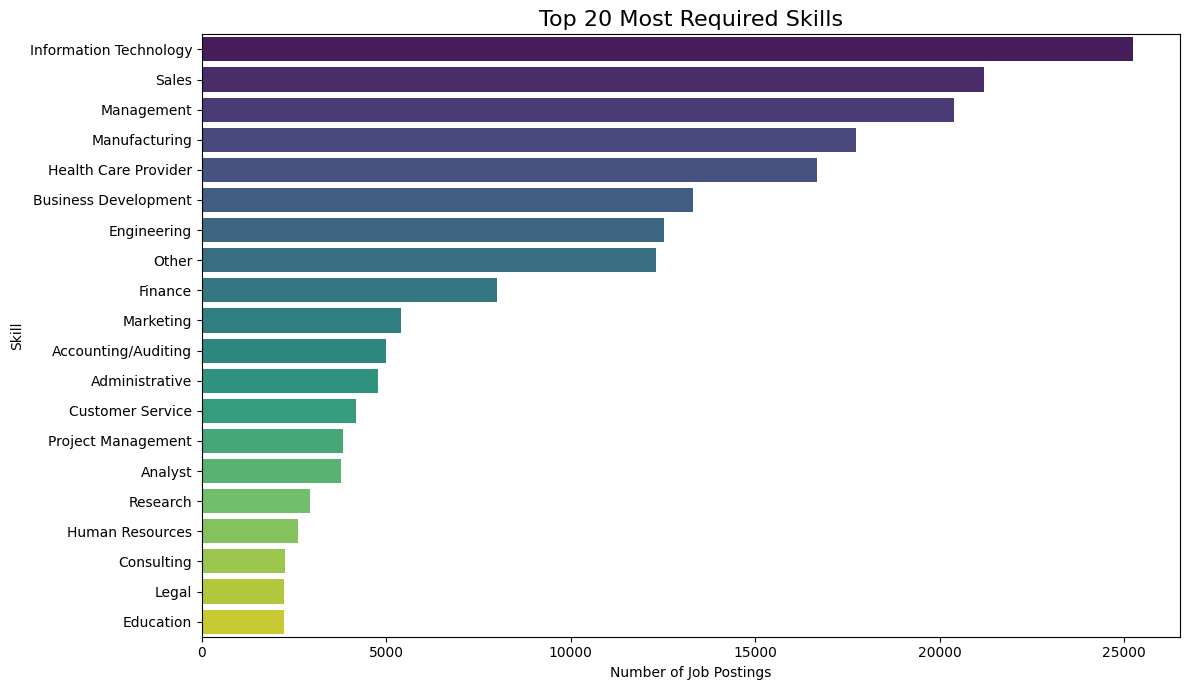

                skill_name  count
0   Information Technology  25256
1                    Sales  21193
2               Management  20385
3            Manufacturing  17728
4     Health Care Provider  16675
5     Business Development  13304
6              Engineering  12530
7                    Other  12314
8                  Finance   8011
9                Marketing   5400
10     Accounting/Auditing   4999
11          Administrative   4787
12        Customer Service   4167
13      Project Management   3825
14                 Analyst   3775
15                Research   2928
16         Human Resources   2608
17              Consulting   2241
18                   Legal   2229
19               Education   2217


In [3]:
# Top 20 Most Required Skills
top_skills = df['skill_name'].value_counts().head(20).reset_index()
top_skills.columns = ['skill_name', 'count']

plt.figure(figsize=(12, 7))
sns.barplot(data=top_skills, x='count', y='skill_name', hue='skill_name', legend=False, palette='viridis')
plt.title('Top 20 Most Required Skills', fontsize=16)
plt.xlabel('Number of Job Postings')
plt.ylabel('Skill')
plt.tight_layout()
plt.savefig(r'C:\Users\mydwm\OneDrive\Desktop\job_market_analysis\output\top_skills.png', dpi=150)
plt.show()

print(top_skills)

In [4]:
roles = {
    'Data Analyst': df_main[df_main['title'].str.contains('Data Analyst', case=False, na=False)],
    'Data Scientist': df_main[df_main['title'].str.contains('Data Scientist', case=False, na=False)],
    'Web Developer': df_main[df_main['title'].str.contains('Web Developer', case=False, na=False)]
}

for role, data in roles.items():
    print(f"{role}: {len(data):,} jobs")

Data Analyst: 408 jobs
Data Scientist: 247 jobs
Web Developer: 66 jobs


             Role  Avg Salary  Min Salary  Max Salary  Count
0    Data Analyst    105312.0     47840.0    222650.0    130
1  Data Scientist    155478.0        45.0    252844.0     89
2   Web Developer    111639.0     55000.0    161200.0     11


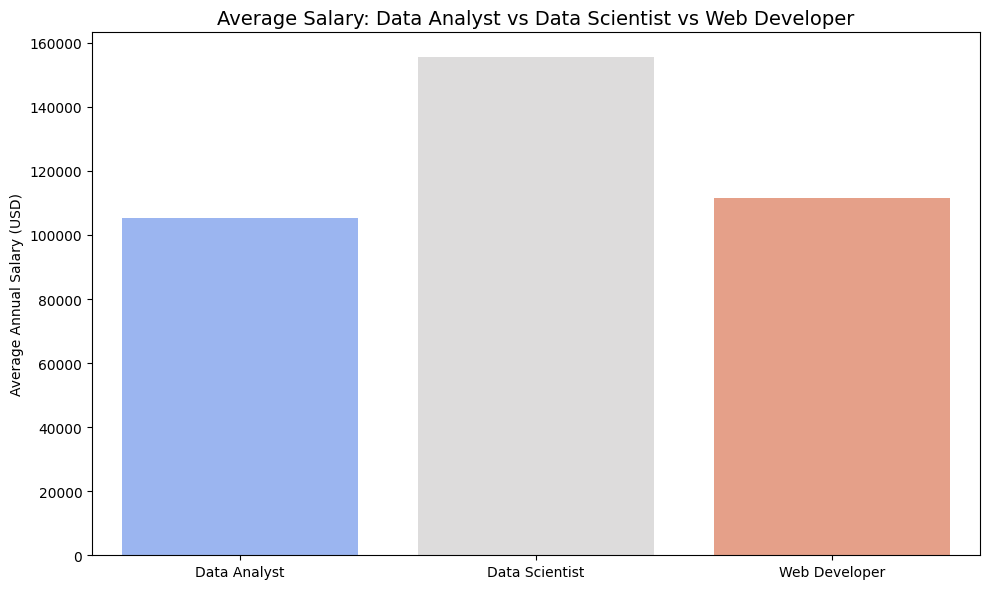

In [5]:
import warnings
warnings.filterwarnings('ignore')

role_salary = []
for role, data in roles.items():
    salary_data = data['normalized_salary'].dropna()
    role_salary.append({
        'Role': role,
        'Avg Salary': salary_data.mean(),
        'Min Salary': salary_data.min(),
        'Max Salary': salary_data.max(),
        'Count': len(salary_data)
    })

salary_df = pd.DataFrame(role_salary)
print(salary_df.round(0))

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=salary_df, x='Role', y='Avg Salary', hue='Role', legend=False, palette='coolwarm')
plt.title('Average Salary: Data Analyst vs Data Scientist vs Web Developer', fontsize=14)
plt.ylabel('Average Annual Salary (USD)')
plt.xlabel('')
plt.tight_layout()
plt.savefig(r'C:\Users\mydwm\OneDrive\Desktop\job_market_analysis\output\salary_comparison.png', dpi=150)
plt.show()

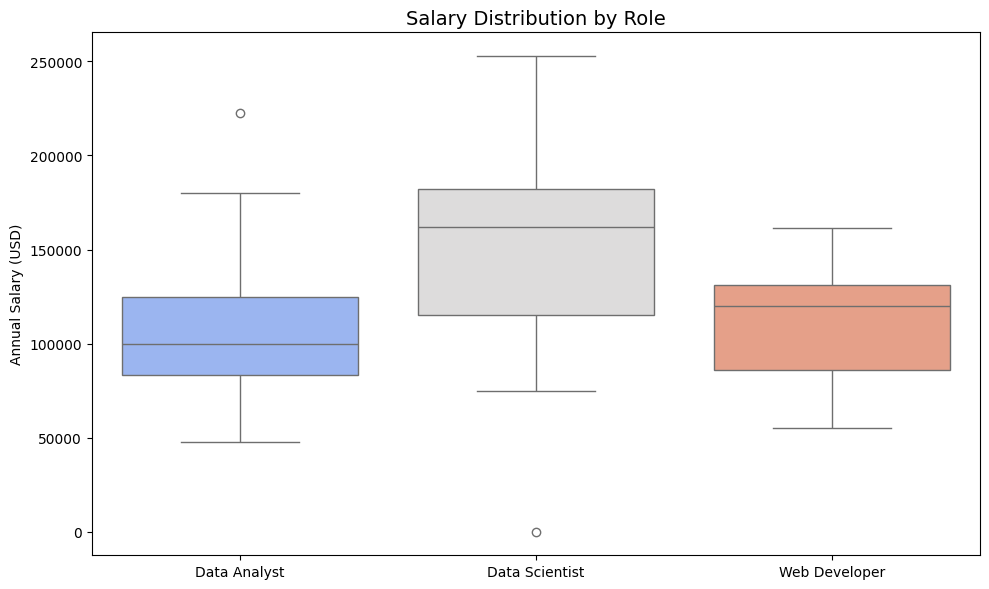

In [6]:
role_list = []
for role, data in roles.items():
    temp = data[['normalized_salary']].dropna().copy()
    temp['Role'] = role
    role_list.append(temp)

salary_plot_df = pd.concat(role_list)

plt.figure(figsize=(10, 6))
sns.boxplot(data=salary_plot_df, x='Role', y='normalized_salary', 
            hue='Role', legend=False, palette='coolwarm')
plt.title('Salary Distribution by Role', fontsize=14)
plt.ylabel('Annual Salary (USD)')
plt.xlabel('')
plt.tight_layout()
plt.savefig(r'C:\Users\mydwm\OneDrive\Desktop\job_market_analysis\output\salary_boxplot.png', dpi=150)
plt.show()

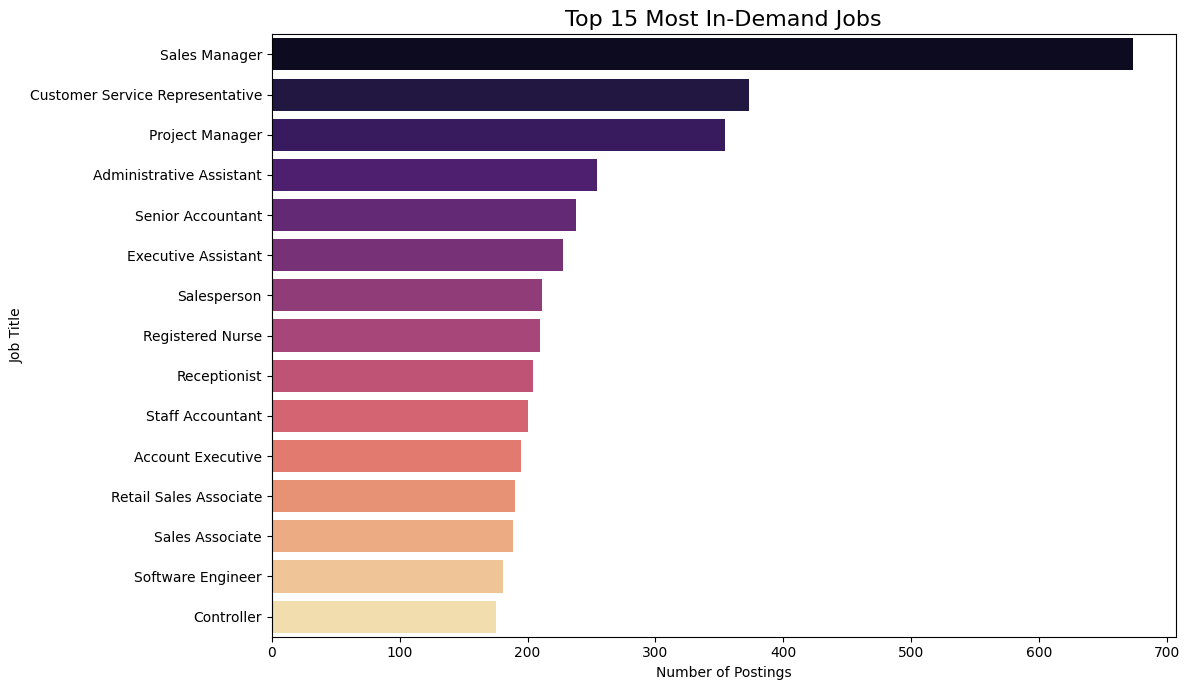

                              title  count
0                     Sales Manager    673
1   Customer Service Representative    373
2                   Project Manager    354
3          Administrative Assistant    254
4                 Senior Accountant    238
5               Executive Assistant    228
6                       Salesperson    211
7                  Registered Nurse    210
8                      Receptionist    204
9                  Staff Accountant    200
10                Account Executive    195
11           Retail Sales Associate    190
12                  Sales Associate    189
13                Software Engineer    181
14                       Controller    175


In [7]:
# Top 15 Most In-Demand Job Titles
top_jobs = df_main['title'].value_counts().head(15).reset_index()
top_jobs.columns = ['title', 'count']

plt.figure(figsize=(12, 7))
sns.barplot(data=top_jobs, x='count', y='title', 
            hue='title', legend=False, palette='magma')
plt.title('Top 15 Most In-Demand Jobs', fontsize=16)
plt.xlabel('Number of Postings')
plt.ylabel('Job Title')
plt.tight_layout()
plt.savefig(r'C:\Users\mydwm\OneDrive\Desktop\job_market_analysis\output\top_jobs.png', dpi=150)
plt.show()

print(top_jobs)

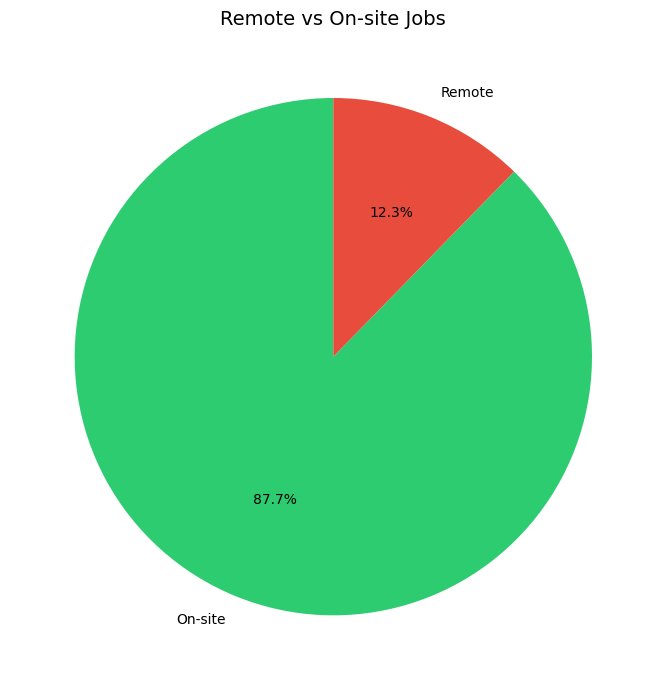

    remote   count
0  On-site  108603
1   Remote   15246


In [8]:
# Remote vs On-site
remote = df_main['remote_allowed'].fillna(0)
remote_counts = remote.value_counts().reset_index()
remote_counts.columns = ['remote', 'count']
remote_counts['remote'] = remote_counts['remote'].map({1.0: 'Remote', 0.0: 'On-site'})

plt.figure(figsize=(7, 7))
plt.pie(remote_counts['count'], labels=remote_counts['remote'], 
        autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
plt.title('Remote vs On-site Jobs', fontsize=14)
plt.tight_layout()
plt.savefig(r'C:\Users\mydwm\OneDrive\Desktop\job_market_analysis\output\remote_vs_onsite.png', dpi=150)
plt.show()

print(remote_counts)

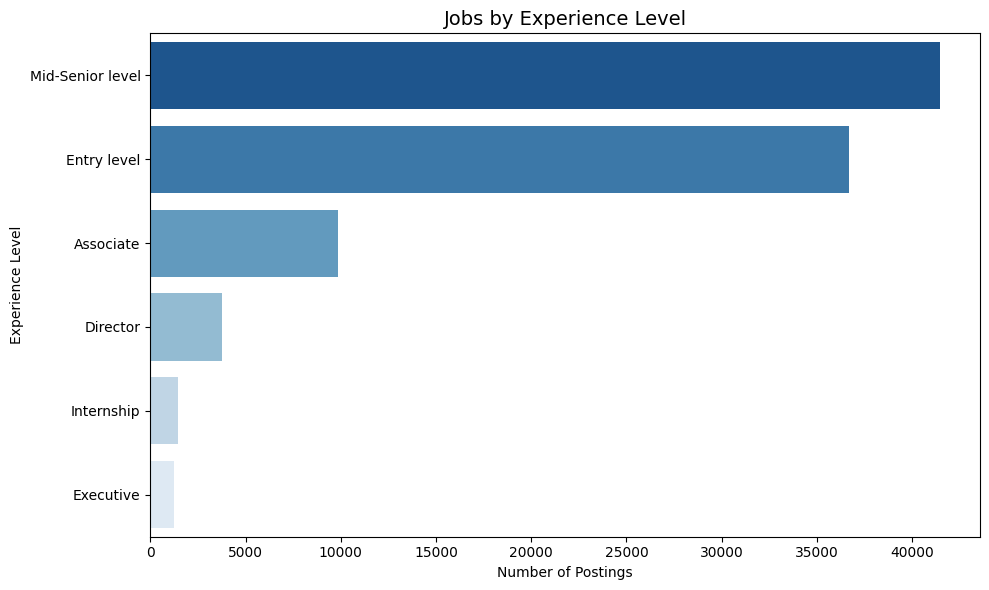

              level  count
0  Mid-Senior level  41489
1       Entry level  36708
2         Associate   9826
3          Director   3746
4        Internship   1449
5         Executive   1222


In [9]:
# Experience Level Distribution
exp = df_main['formatted_experience_level'].value_counts().reset_index()
exp.columns = ['level', 'count']

plt.figure(figsize=(10, 6))
sns.barplot(data=exp, x='count', y='level',
            hue='level', legend=False, palette='Blues_r')
plt.title('Jobs by Experience Level', fontsize=14)
plt.xlabel('Number of Postings')
plt.ylabel('Experience Level')
plt.tight_layout()
plt.savefig(r'C:\Users\mydwm\OneDrive\Desktop\job_market_analysis\output\experience_level.png', dpi=150)
plt.show()

print(exp)

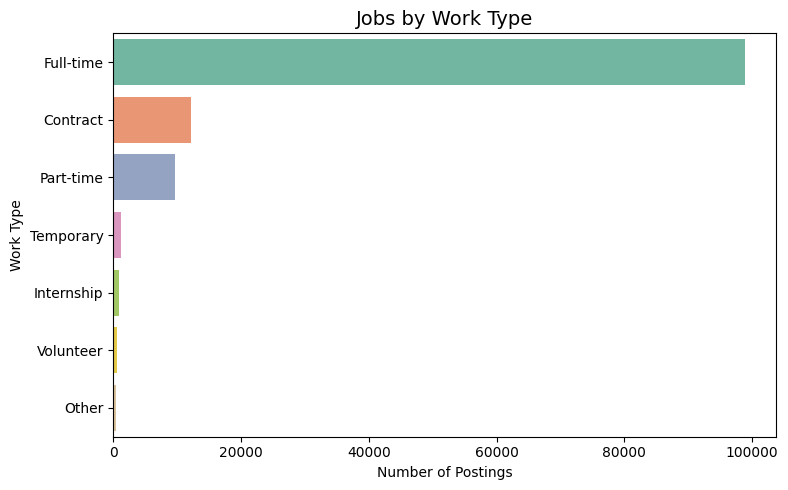

         type  count
0   Full-time  98814
1    Contract  12117
2   Part-time   9696
3   Temporary   1190
4  Internship    983
5   Volunteer    562
6       Other    487


In [10]:
# Work Type Distribution
work = df_main['formatted_work_type'].value_counts().reset_index()
work.columns = ['type', 'count']

plt.figure(figsize=(8, 5))
sns.barplot(data=work, x='count', y='type',
            hue='type', legend=False, palette='Set2')
plt.title('Jobs by Work Type', fontsize=14)
plt.xlabel('Number of Postings')
plt.ylabel('Work Type')
plt.tight_layout()
plt.savefig(r'C:\Users\mydwm\OneDrive\Desktop\job_market_analysis\output\work_type.png', dpi=150)
plt.show()

print(work)

In [12]:
import sqlite3

db_path = r'C:\Users\mydwm\OneDrive\Desktop\job_market_analysis\output\jobs.db'

conn = sqlite3.connect(db_path)

df_main.to_sql('jobs', conn, if_exists='replace', index=False)
df.to_sql('jobs_skills', conn, if_exists='replace', index=False)

cursor = conn.cursor()
cursor.execute("SELECT COUNT(*) FROM jobs")
print("Jobs rows:", cursor.fetchone()[0])

cursor.execute("SELECT COUNT(*) FROM jobs_skills")
print("Skills rows:", cursor.fetchone()[0])

conn.commit()
conn.close()
print("✅ Done!")

Jobs rows: 123849
Skills rows: 207531
✅ Done!
